# Luddite Maps


In [3]:
import os
from pathlib import Path
from fastkml import kml
from shapely.geometry import mapping
import geopandas as gpd
import pandas as pd
import json

DATA_DIR = Path("data")

geojson_files = list(DATA_DIR.glob("*.geojson"))
gdfs = [gpd.read_file(f) for f in geojson_files]

gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs="EPSG:4326")

gdf

,Name,tessellate,extrude,visibility,geometry,id,fontSize,fontFamily,fontColor,fontWeight,...,strokeColor,strokeStyle,strokeWidth,strokeOpacity,strokeLinecap,internal,marker,pointRadius,hideOverlap,fcode
0,Huddersfield and Penistone Turnpike,1,0,-1,"LINESTRING Z (-1.73612 53.64516 0, -1.73578 53...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Shelley Branch of the Huddersfield and Penisto...,1,0,-1,"MULTILINESTRING Z ((-1.69296 53.59758 0, -1.69...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,-1,0,-1,"LINESTRING (-1.67093 53.57048, -1.67 53.57058,...",OpenLayers_Feature_Vector_1,24px,Arial,#000000,bold,...,#800080,solid,3.0,1.0,round,0.0,0.0,15.0,0.0,1.0
3,Dunford District Turnpike,1,0,-1,"LINESTRING Z (-1.75772 53.51998 0, -1.7578 53....",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Barnsley and Shepley Lane Head Turnpike,1,0,-1,"LINESTRING Z (-1.70592 53.5748 0, -1.70327 53....",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Meltham and Wessenden Head Turnpike Road,1,0,-1,"LINESTRING Z (-1.85055 53.59182 0, -1.8516 53....",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Holmfirth District Turnpike,1,0,-1,"LINESTRING Z (-1.78632 53.56978 0, -1.78594 53...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Wadsley and Langsett Turnpike Road,1,0,-1,"LINESTRING Z (-1.78822 53.60547 0, -1.78801 53...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Lockwood and Meltham Turnpike Road,1,0,-1,"LINESTRING Z (-1.7825 53.64642 0, -1.78271 53....",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Greenfield and Shepley Lane Head Turnpike Road,1,0,-1,"LINESTRING Z (-1.99865 53.53254 0, -1.9981 53....",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

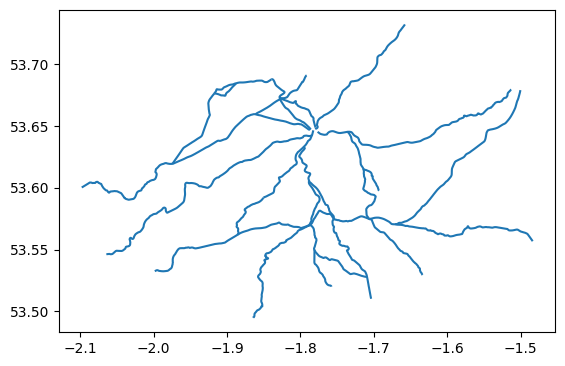

In [4]:
gdf.plot()

In [15]:
import json
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# 1. Load JSON
with open("data/locationsAll.json", "r") as f:
    data = json.load(f)

# 2. Normalize JSON into a flat table
records = []
for item in data:
    # Each item in your JSON file
    record = {
        "pageID": item.get("pageID"),
        "title": item.get("title"),
        "categories": item.get("categories"),
        "boundaries": item.get("boundaries"),
        "address": item["geo"].get("address"),
        "height": item["geo"].get("height"),
        "lati": item["geo"].get("lati"),
        "long": item["geo"].get("long"),
        "os": item["geo"].get("os"),
    }
    # Add a geometry column
    record["geometry"] = Point(record["long"], record["lati"])
    records.append(record)

# 3. Create a GeoDataFrame
points_gdf = gpd.GeoDataFrame(records, geometry="geometry")

# 4. Set a coordinate reference system (WGS84)
points_gdf.set_crs(epsg=4326, inplace=True).to_crs(gdf.crs)
points_gdf

,pageID,title,categories,boundaries,address,height,lati,long,os,geometry
0,19,"Carlile Institute, Meltham","[Buildings, Meltham Blue Plaque Trail]","[{'name': 'Almondbury', 'pageID': 10134, 'type...","Huddersfield Road, Meltham, Holmfirth, HD9 4AG",184,53.592387,-1.848527,SE 10124 10654,POINT (-1.84853 53.59239)
1,85,Beaumont Park,"[Parks and pleasure grounds, Listed buildings ...","[{'name': 'Lockwood', 'pageID': 302, 'type': '...","Beaumont Park Road, Huddersfield, HD4 7AU",157,53.624403,-1.810957,SE 12601 14222,POINT (-1.81096 53.6244)
2,153,"Pleasure Grounds, Meltham","[Parks and pleasure grounds, Locations on the ...","[{'name': 'Meltham', 'pageID': 190, 'type': 't...","Acre Lane, Meltham, Holmfirth, HD9 4DH",182,53.589779,-1.841966,SE 10558 10365,POINT (-1.84197 53.58978)
3,156,"Ramsden Building, Queen Street South, Huddersf...","[Buildings, Schools, Buildings on the Universi...","[{'name': 'Huddersfield', 'pageID': 10137, 'ty...","Page Street, Huddersfield, HD1 3DR",81,53.642843,-1.780012,SE 14641 16280,POINT (-1.78001 53.64284)
4,166,"Wills O&#39; Nats, Meltham","[Public houses, beerhouses, inns, etc., Public...","[{'name': 'Almondbury', 'pageID': 10134, 'type...","Blackmoorfoot Road, Holmfirth, HD9 5PS",275,53.605191,-1.865120,SE 09023 12077,POINT (-1.86512 53.60519)
...,...,...,...,...,...,...,...,...,...,...
11080,76920,"Clay Pit, Kirkheaton Brick Works, Lane Side, K...",[Clay pits],"[{'name': 'Kirkheaton', 'pageID': 10530, 'type...",None,103,53.652199,-1.718047,SE 18734 17335,POINT (-1.71805 53.6522)
11081,76921,"Brechin Terrace, Meltham",[Buildings],"[{'name': 'Meltham', 'pageID': 190, 'type': 't...","Mean Lane, Meltham, Holmfirth, HD9 5QS",171,53.595130,-1.847924,SE 10163 10960,POINT (-1.84792 53.59513)
11082,76928,"Moorcroft, Warehouse Lane, Highburton",[Buildings],"[{'name': 'Kirkburton', 'pageID': 10136, 'type...","Primrose Lane, Kirkburton, Huddersfield, HD8 0QZ",122,53.620680,-1.715729,SE 18901 13829,POINT (-1.71573 53.62068)
11083,76931,"Green Gove Mills, Warehouse Lane, Highburton","[Buildings, Mills]","[{'name': 'High Burton', 'pageID': 16793, 'typ...",None,134,53.619535,-1.714331,SE 18994 13702,POINT (-1.71433 53.61954)


In [36]:
names = [
    "Cleckheaton"

]

filtered_points_gdf_ = points_gdf[
    points_gdf["title"].str.contains("|".join(names), case=False, na=False)
]
filtered_points_gdf_

,pageID,title,categories,boundaries,address,height,lati,long,os,geometry


In [ ]:
_ids = [25526, 17340, 353, 4507]

filtered_points_gdf = points_gdf[
    points_gdf["pageID"].isin(_ids)
]
filtered_points_gdf

,pageID,title,categories,boundaries,address,height,lati,long,os,geometry
10,353,Dungeon Wood,[Woods],"[{'name': 'Lockwood', 'pageID': 302, 'type': '...","Beaumont Park Road, Huddersfield, HD4 5JN",135,53.627340,-1.807306,SE 12842 14550,POINT (-1.80731 53.62734)
8599,17340,"Dumb Steeple, Cooper Bridge",[Listed buildings and monuments],[],"Wakefield Road, Mirfield, WF14 0BT",53,53.685944,-1.731655,SE 17820 21086,POINT (-1.73166 53.68594)
9871,25526,"Warren House Inn, Blackmoorfoot Road, Crosland...","[Buildings, Public houses, beerhouses, inns, e...","[{'name': 'North Crosland', 'pageID': 16749, '...","Charles Street, Crosland Moor, Huddersfield, H...",138,53.637405,-1.810459,SE 12630 15669,POINT (-1.81046 53.6374)


In [31]:
from geopy.geocoders import Nominatim
from shapely.geometry import Point

geolocator = Nominatim(user_agent="my_app")

# Define locations to geocode
locations = [
    ("Almondbury", "Almondbury, West Yorkshire, UK"),
    ("Huddersfield", "Huddersfield, West Yorkshire, UK"),
    # ("The Pepperpot", "St Catherine's Oratory"),
    # ("Godshill", "Godshill"),
]

# Geocode all locations and create points
geocoded_data = []
for name, address in locations:
    location = geolocator.geocode(address)
    geocoded_data.append(
        {
            "name": name,
            "x_offset": 0,
            "y_offset": 0,
            "geometry": Point(location.longitude, location.latitude),
        }
    )

# Create GeoDataFrame
point_gdf = gpd.GeoDataFrame(geocoded_data, crs="EPSG:4326").to_crs(gdf.crs)
# location = geolocator.geocode("Puckaster, Isle of Wight, UK")
point_gdf

GeocoderUnavailable: HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /search?q=Huddersfield%2C+West+Yorkshire%2C+UK&format=json&limit=1 (Caused by ReadTimeoutError("HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Read timed out. (read timeout=1)"))

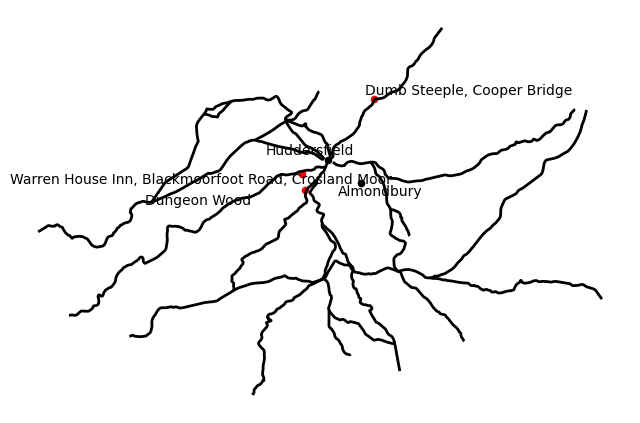

In [28]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

feature_color = "black"

fig, ax = plt.subplots(figsize=(8, 8))
# fig.patch.set_alpha(0)  # Transparent figure background

ax = gdf.plot(
    ax=ax, figsize=(8, 8), edgecolor=feature_color, facecolor="none", linewidth=2
)
ax = point_gdf.plot(ax=ax, color=feature_color, markersize=20)

ax = filtered_points_gdf.plot(ax=ax, color="red", markersize=20)

add_label = lambda row: ax.annotate(
    row["name"],
    xy=(row.geometry.x, row.geometry.y),
    xytext=(row.geometry.x + row["x_offset"], row.geometry.y + row["y_offset"]),
    fontsize=10,
    ha="center",
    va="center",
    color=feature_color,  # White text color
    # bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.7)
)
add_label2 = lambda row: ax.annotate(
    row["title"],
    xy=(row.geometry.x, row.geometry.y),
    xytext=(row.geometry.x, row.geometry.y),
    fontsize=10,
    ha="center",
    va="center",
    color=feature_color,  # White text color
    # bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.7)
)

texts = point_gdf.apply(add_label, axis=1).tolist()
adjust_text(
    texts,
    # arrowprops=dict(arrowstyle="->", color="white", lw=0.5)
    avoid_self=True,
)

texts2 = filtered_points_gdf.apply(add_label2, axis=1).tolist()
adjust_text(
    texts2,
    # arrowprops=dict(arrowstyle="->", color="white", lw=0.5)
    avoid_self=True,
)

ax.set_facecolor("none")  # Transparent axes background
ax.axis("off")

plt.savefig("test_map.png", dpi=300, bbox_inches="tight", transparent=True)

# Additional locations

Rawfolds